In [41]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt


In [31]:
#read results as dataframes
baseline_df = pd.read_csv("/Users/manan/llm-inference-scaling/results/baseline_api_results.csv")
adaptive_df = pd.read_csv("/Users/manan/llm-inference-scaling/results/adaptive_results.csv")
cot_df = pd.read_csv("/Users/manan/llm-inference-scaling/results/cot_results.csv")
self_consistency_df = pd.read_csv("/Users/manan/llm-inference-scaling/results/self_consistency_results.csv")

dataframes = [baseline_df, adaptive_df, cot_df, self_consistency_df]

In [32]:
#encode Boolean column as integers
le = LabelEncoder()

for df in dataframes:
    df['correct'] = le.fit_transform(df['correct'])  

In [43]:
#get simple accuracy score
accuracies = []
strategies = ['Baseline', 'Adaptive', 'Chain of Thought', 'Self-Consistency']

for df in dataframes:
    accuracy = df['correct'].mean()
    accuracies.append(accuracy)


#print(f"Baseline accuracy: {baseline_accuracy:.2f}")

accuracies_dict = dict(zip(strategies, accuracies))
print(f"{accuracies_dict}.2f")

{'Baseline': np.float64(0.48), 'Adaptive': np.float64(0.58), 'Chain of Thought': np.float64(0.44), 'Self-Consistency': np.float64(0.12666666666666668)}.2f


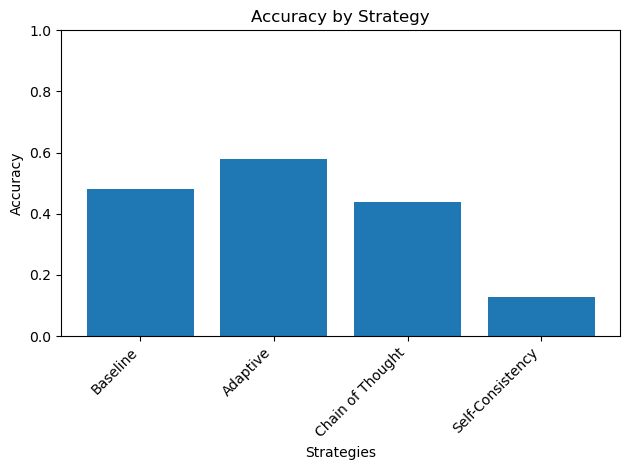

In [44]:
#plot accuracies
accuracies = list(accuracies_dict.values())

bars = plt.bar(strategies, accuracies)
plt.xlabel('Strategies')
plt.ylabel('Accuracy')
plt.title('Accuracy by Strategy')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Accuracies not very good
- CoT pretty much same as baseline
- Self-consistency performs very poorlydepsite being the most involved strategy -> compare results to existing papers
- Why does Adaptive do the best? balance of cheap token cost + meaningful strategy?
- Local model limitations? Try using open-source model API, HF Transformers
- 

In [55]:
#total tokens used for each strategy
baseline_df = baseline_df.rename(columns={'tokens': 'tokens_used'})
cot_df = cot_df.rename(columns={'budget': 'tokens_used'})
self_consistency_df['tokens_used'] = 100


tokens_totals = {
    'Baseline': baseline_df['tokens_used'].sum(),
    'Adaptive': adaptive_df['tokens_used'].sum(), 
    'CoT': cot_df['tokens_used'].sum(),
    'Self-Consistency': self_consistency_df['tokens_used'].sum()
}

print("Total tokens per strategy:", tokens_totals)

Total tokens per strategy: {'Baseline': np.int64(2500), 'Adaptive': np.int64(4700), 'CoT': np.int64(35000), 'Self-Consistency': np.int64(15000)}


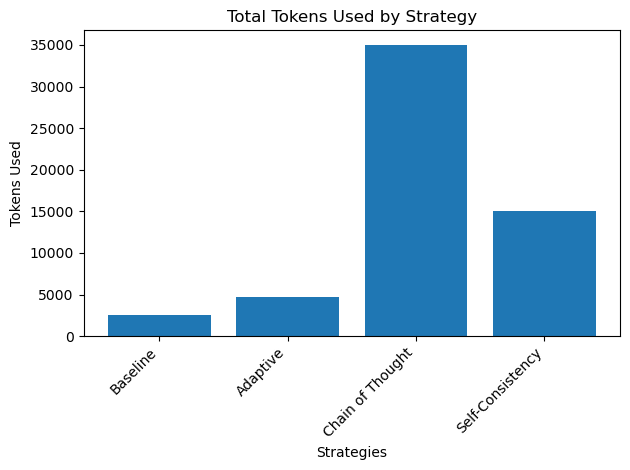

In [58]:
accuracies = list(accuracies_dict.values())

bars = plt.bar(strategies, list(tokens_totals.values()))
plt.xlabel('Strategies')
plt.ylabel('Tokens Used')
plt.title('Total Tokens Used by Strategy')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

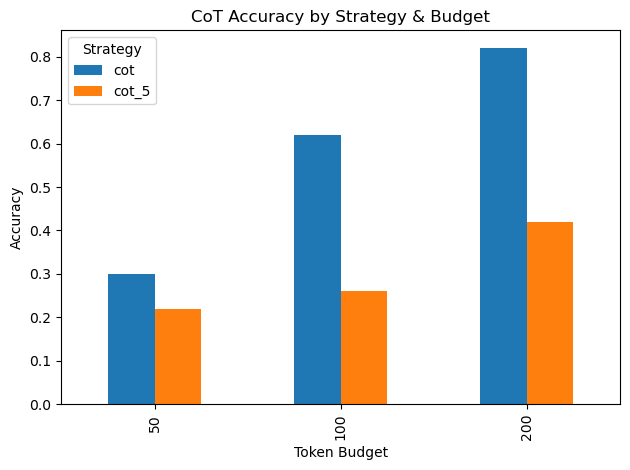

In [59]:
#exploring cot
grouped = cot_df.groupby(["strategy", "tokens_used"])["correct"].mean().reset_index()
pivot = grouped.pivot(index="tokens_used", columns="strategy", values="correct")

ax = pivot.plot(kind="bar")
ax.set_title("CoT Accuracy by Strategy & Budget")
ax.set_xlabel("Token Budget")
ax.set_ylabel("Accuracy")
ax.legend(title="Strategy")
plt.tight_layout()
plt.show()


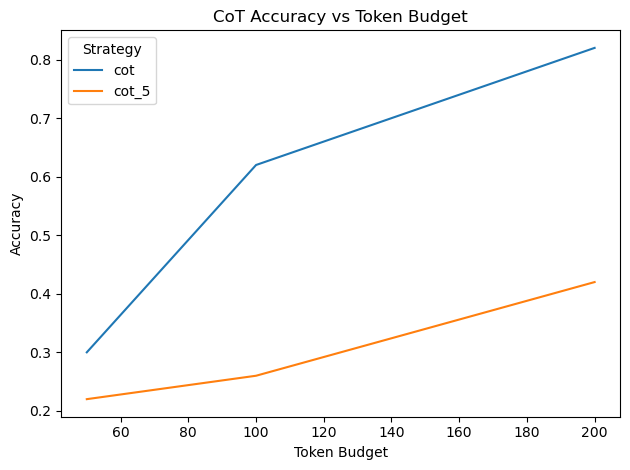

In [62]:
strategies = grouped["strategy"].unique()

for s in strategies:
    subset = grouped[grouped["strategy"] == s]
    plt.plot(subset["tokens_used"], subset["correct"], label=s)

plt.title("CoT Accuracy vs Token Budget")
plt.xlabel("Token Budget")
plt.ylabel("Accuracy")
plt.legend(title="Strategy")

plt.tight_layout()
plt.show()

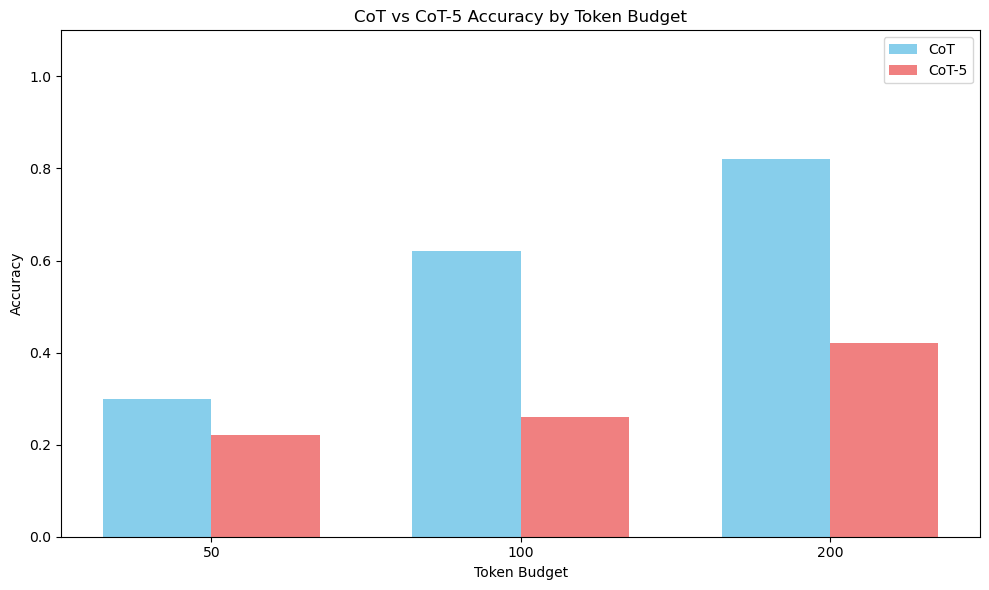

In [64]:
accuracy_data = cot_df.groupby(['strategy', 'tokens_used'])['correct'].mean().unstack()

TOKEN_BUDGETS =[50,100,200]
# Plot
fig, ax = plt.subplots(figsize=(10, 6))
strategies = accuracy_data.index
x_pos = np.arange(len(TOKEN_BUDGETS))  # [50,100,200]

width = 0.35
ax.bar(x_pos - width/2, accuracy_data.loc['cot'], width, label='CoT', color='skyblue')
ax.bar(x_pos + width/2, accuracy_data.loc['cot_5'], width, label='CoT-5', color='lightcoral')

ax.set_xlabel('Token Budget')
ax.set_ylabel('Accuracy')
ax.set_title('CoT vs CoT-5 Accuracy by Token Budget')
ax.set_xticks(x_pos)
ax.set_xticklabels(TOKEN_BUDGETS)
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

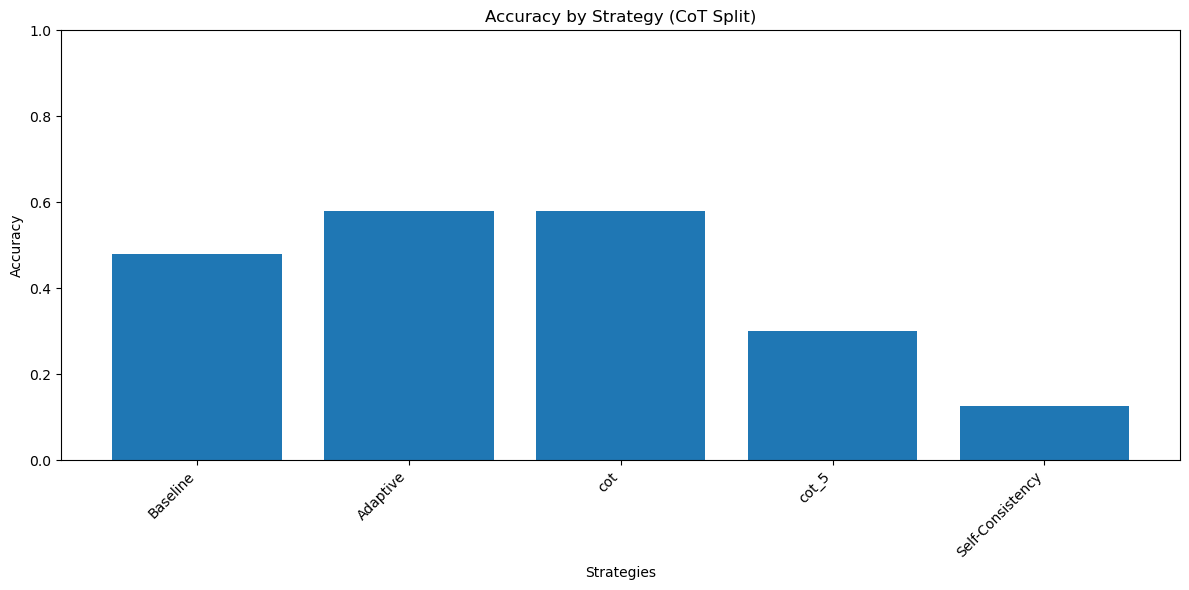

In [65]:
cot_acc = cot_df[cot_df['strategy'] == 'cot']['correct'].mean()
cot5_acc = cot_df[cot_df['strategy'] == 'cot_5']['correct'].mean()

# Updated lists (replace CoT with cot/cot_5)
strategies = ['Baseline', 'Adaptive', 'cot', 'cot_5', 'Self-Consistency']
accuracies = [0.48, 0.58, cot_acc, cot5_acc, 0.1267]

# Your plot code
plt.figure(figsize=(12, 6))
bars = plt.bar(strategies, accuracies)
plt.xlabel('Strategies')
plt.ylabel('Accuracy')
plt.title('Accuracy by Strategy (CoT Split)')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


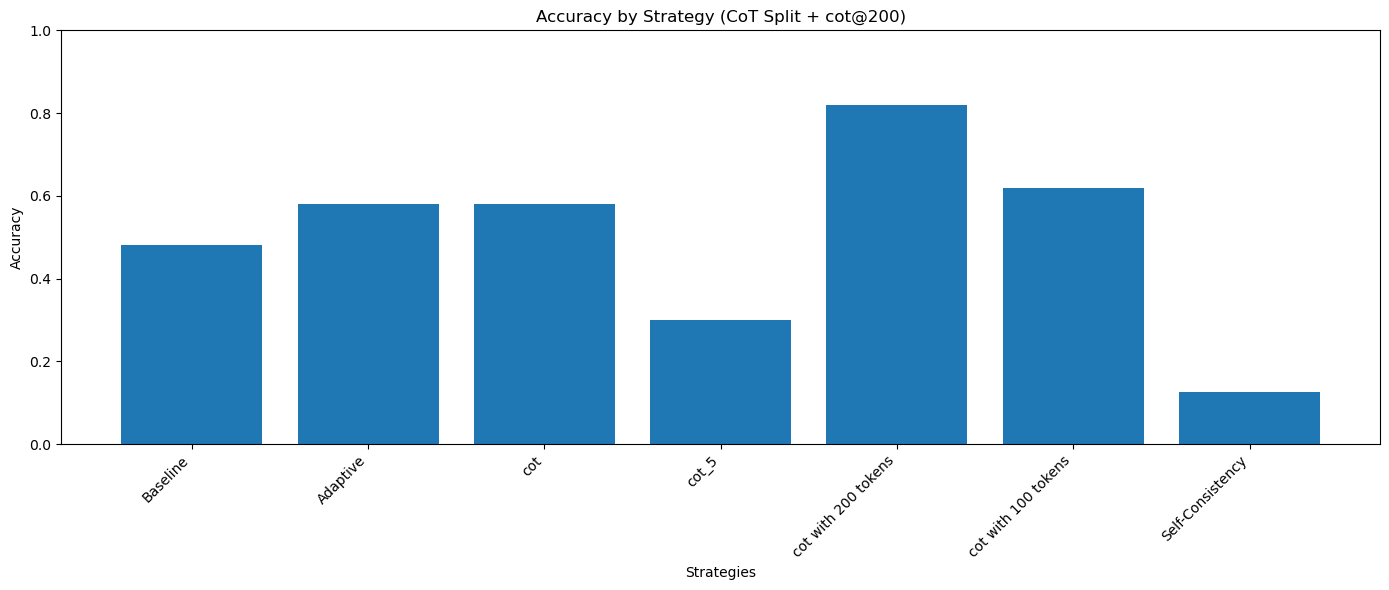

In [67]:
cot_avg = cot_df[cot_df['strategy'] == 'cot']['correct'].mean()
cot5_avg = cot_df[cot_df['strategy'] == 'cot_5']['correct'].mean()
cot_200 = cot_df[(cot_df['strategy'] == 'cot') & (cot_df['tokens_used'] == 200)]['correct'].mean()
cot_100 = cot_df[(cot_df['strategy'] == 'cot') & (cot_df['tokens_used'] == 100)]['correct'].mean()


strategies = ['Baseline', 'Adaptive', 'cot', 'cot_5', 'cot with 200 tokens','cot with 100 tokens', 'Self-Consistency']
accuracies = [0.48, 0.58, cot_avg, cot5_avg, cot_200, cot_100, 0.1267]

plt.figure(figsize=(14, 6))
bars = plt.bar(strategies, accuracies)
plt.xlabel('Strategies')
plt.ylabel('Accuracy')
plt.title('Accuracy by Strategy (CoT Split + cot@200)')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


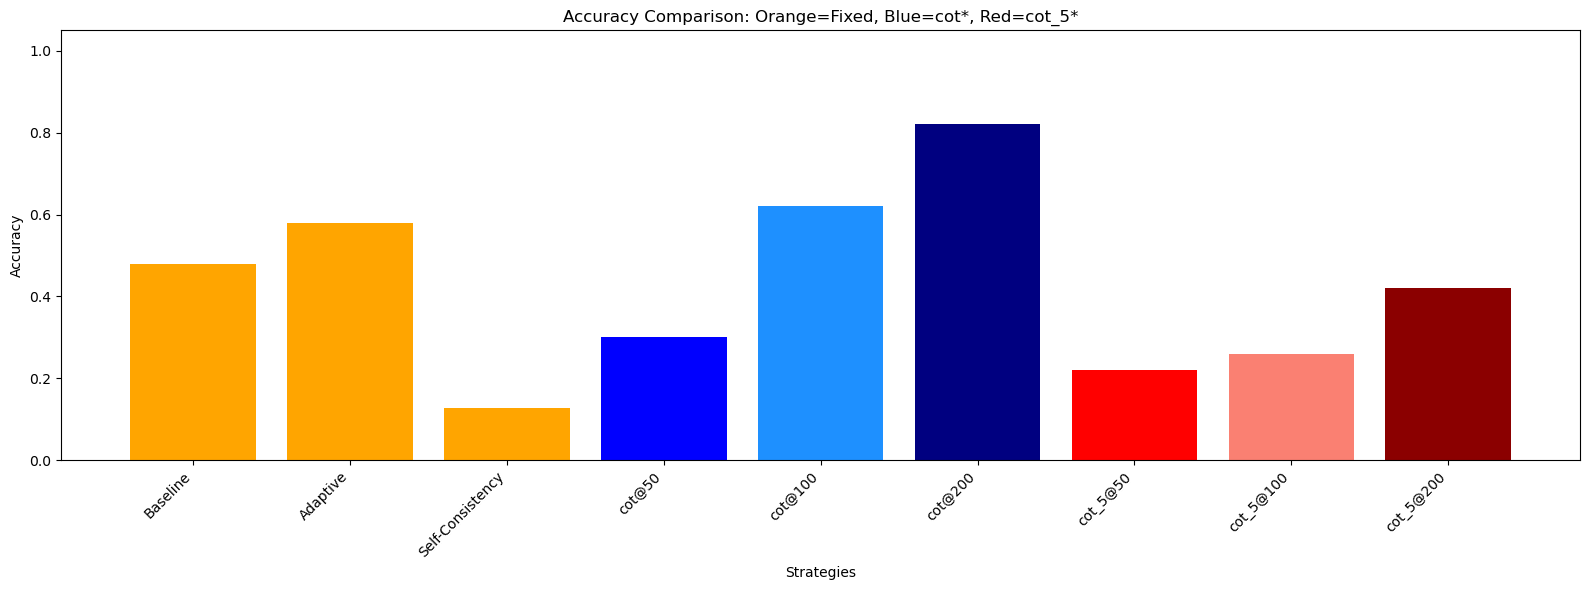

In [68]:
cot_50 = cot_df[(cot_df['strategy']=='cot') & (cot_df['tokens_used']==50)]['correct'].mean()
cot_100 = cot_df[(cot_df['strategy']=='cot') & (cot_df['tokens_used']==100)]['correct'].mean()
cot_200 = cot_df[(cot_df['strategy']=='cot') & (cot_df['tokens_used']==200)]['correct'].mean()
cot5_50 = cot_df[(cot_df['strategy']=='cot_5') & (cot_df['tokens_used']==50)]['correct'].mean()
cot5_100 = cot_df[(cot_df['strategy']=='cot_5') & (cot_df['tokens_used']==100)]['correct'].mean()
cot5_200 = cot_df[(cot_df['strategy']=='cot_5') & (cot_df['tokens_used']==200)]['correct'].mean()

labels = ['Baseline', 'Adaptive', 'Self-Consistency', 
          'cot@50', 'cot@100', 'cot@200', 
          'cot_5@50', 'cot_5@100', 'cot_5@200']
accuracies = [0.48, 0.58, 0.1267, cot_50, cot_100, cot_200, cot5_50, cot5_100, cot5_200]

colors = ['orange']*3 + ['blue', 'dodgerblue', 'navy'] + ['red', 'salmon', 'darkred']

plt.figure(figsize=(16, 6))
bars = plt.bar(labels, accuracies, color=colors)
plt.xlabel('Strategies')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison: Orange=Fixed, Blue=cot*, Red=cot_5*')
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Choice of tokens is arbitrary 

100 tokens ≈ 75 words, 1 paragraph

30-40 words should be enough for model to generate answer to simple reasoning tasks <- find a source to back up this claim


at 200 tokens, cot performs well. should be increase the token count for baseline and adaptive?


In [53]:
print(cot_df['budget'])

0       50
1      100
2      200
3       50
4      100
      ... 
295    100
296    200
297     50
298    100
299    200
Name: budget, Length: 300, dtype: int64
